# ebmcmc Demo: Fitting a Synthetic Eclipsing Binary

This notebook demonstrates the full `ebmcmc` pipeline on a **synthetic eclipsing binary** generated with PHOEBE. We fit all three data types simultaneously:

- **Light curves** (photometry)
- **Radial velocities** (spectroscopy)
- **Broadband SED** (multi-band photometry)

The `has_rv` and `has_sed` flags are independent, so `ebmcmc` supports any combination: LC-only, LC+SED, LC+RV, or the full LC+SED+RV joint fit shown here.

**Requirements:** `phoebe`, `ebmcmc`, `binarysed`, `matplotlib`, `numpy`, `corner` (optional)

> **Note:** Real science runs use `max_n=100000` (the default) with 32+ walkers and 16+ threads on an HPC cluster. This demo uses short runs to keep execution time reasonable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import phoebe
import logging

from ebmcmc import EBMCMC
from ebmcmc.loglike import transform_params, logit, sigmoid

# Suppress PHOEBE's verbose output
phoebe.logger(clevel="WARNING")
phoebe.interactive_checks_off()
phoebe.progressbars_off()
logging.getLogger("ebmcmc").setLevel(logging.INFO)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

/global/homes/j/jrblaum/anaconda3/envs/mcmc/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/global/homes/j/jrblaum/anaconda3/envs/mcmc/lib/python3.10/site-packages/pystellibs/ezunits/pint.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
Thu, 19 Mar 2026 12:42 PHOEBE       WARNING checks will not be run until 'run_checks' or 'run_compute' is called.


## 1. Create a Synthetic Eclipsing Binary

We use PHOEBE's `default_binary()` to set up a detached eclipsing binary with known ("truth") parameters, then generate noisy light curve and radial velocity data.

In [2]:
# --- Truth values ---
TRUTH = {
    "period": 2.5,        # days
    "q": 0.8,             # M2/M1
    "teff1": 6000,        # K
    "teff2": 5200,        # K
    "requiv1": 1.2,       # R_sun
    "requiv2": 0.95,      # R_sun
    "incl": 85.0,         # degrees
    "ecc": 0.05,
    "per0": 90.0,         # degrees
    "t0_supconj": 0.0,    # BJD offset
    "distance": 300.0,    # pc
    "vgamma": -12.0,      # systemic RV (km/s)
}

# Build the PHOEBE bundle
b = phoebe.default_binary()
b.set_value("period@binary@component", TRUTH["period"])
b.set_value("q@binary@component", TRUTH["q"])
b.set_value("teff@primary@component", TRUTH["teff1"])
b.set_value("teff@secondary@component", TRUTH["teff2"])
b.set_value("requiv@primary@component", TRUTH["requiv1"])
b.set_value("requiv@secondary@component", TRUTH["requiv2"])
b.set_value("incl@binary@component", TRUTH["incl"])
b.set_value("ecc@binary@component", TRUTH["ecc"])
b.set_value("per0@binary@component", TRUTH["per0"])
b.set_value("t0_supconj@binary@component", TRUTH["t0_supconj"])
b.set_value("vgamma@system", TRUTH["vgamma"])

# --- Light curve dataset (TESS band, 200 points) ---
times_lc = np.linspace(0, 2 * TRUTH["period"], 200)
b.add_dataset("lc", times=times_lc, dataset="lc01_tess")
b.set_value("passband@lc01_tess", "TESS:T")

# --- Radial velocity dataset (30 observations spread over several orbits) ---
times_rv = np.sort(np.random.default_rng(123).uniform(0, 4 * TRUTH["period"], 30))
b.add_dataset("rv", times=times_rv, dataset="rv01")

# Compute synthetic observables
b.run_compute(compute="phoebe01", model="synthetic")

# --- Add noise to LC ---
fluxes_true = b.get_value("fluxes@model@lc01_tess")
noise_level = 0.005  # 0.5% relative flux noise
np.random.seed(42)
fluxes_noisy = fluxes_true + noise_level * np.random.randn(len(fluxes_true))
sigmas_lc = noise_level * np.ones(len(fluxes_true))

b.set_value("fluxes@lc01_tess@dataset", fluxes_noisy)
b.set_value("sigmas@lc01_tess@dataset", sigmas_lc)

# --- Add noise to RVs ---
rv_noise = 2.0  # km/s
rv1_true = b.get_value("rvs@model@rv01@primary")
rv2_true = b.get_value("rvs@model@rv01@secondary")
rv1_noisy = rv1_true + rv_noise * np.random.randn(len(rv1_true))
rv2_noisy = rv2_true + rv_noise * np.random.randn(len(rv2_true))
sigmas_rv = rv_noise * np.ones(len(rv1_true))

b.set_value("rvs@rv01@primary@dataset", rv1_noisy)
b.set_value("rvs@rv01@secondary@dataset", rv2_noisy)
b.set_value("sigmas@rv01@primary@dataset", sigmas_rv)
b.set_value("sigmas@rv01@secondary@dataset", sigmas_rv)

print(f"Light curve: {len(times_lc)} points, noise = {noise_level:.4f}")
print(f"RV curve: {len(times_rv)} points per component, noise = {rv_noise:.1f} km/s")
print(f"Bundle datasets: {b.datasets}")

Light curve: 200 points, noise = 0.0050
RV curve: 30 points per component, noise = 2.0 km/s
Bundle datasets: ['lc01_tess', 'rv01']


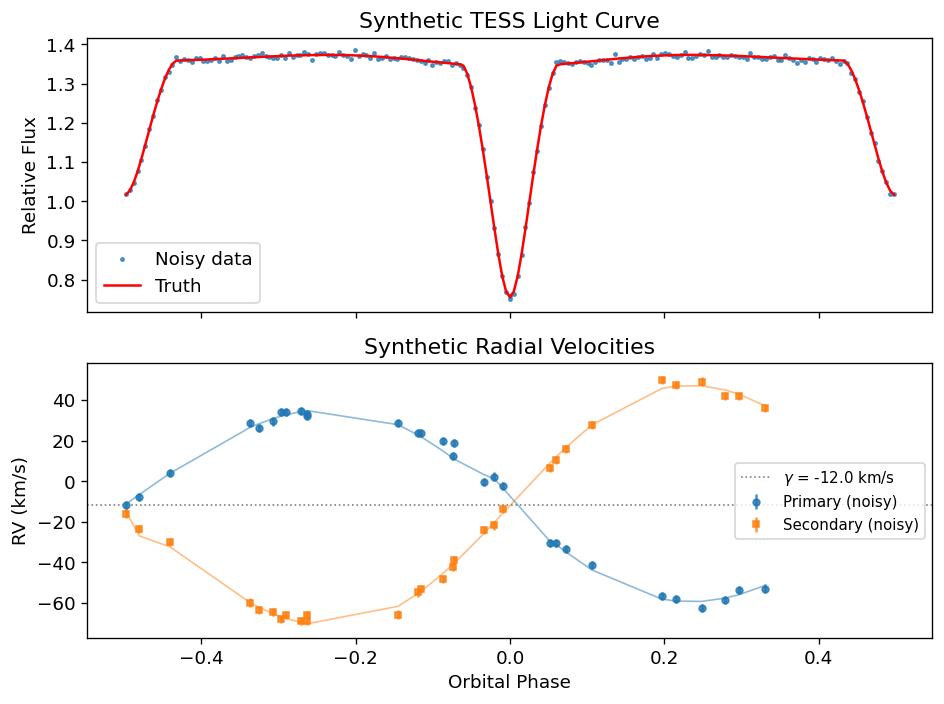

In [3]:
# Plot the synthetic light curve and radial velocities
phases_lc = b.to_phase(times_lc)
phases_rv = b.to_phase(times_rv)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Light curve
ax1.scatter(phases_lc, fluxes_noisy, s=4, alpha=0.7, label="Noisy data")
ax1.plot(np.sort(phases_lc), fluxes_true[np.argsort(phases_lc)], "r-", lw=1.5, label="Truth")
ax1.set_ylabel("Relative Flux")
ax1.set_title("Synthetic TESS Light Curve")
ax1.legend()

# Radial velocities
ax2.errorbar(phases_rv, rv1_noisy, yerr=sigmas_rv, fmt="o", ms=4, alpha=0.8, label="Primary (noisy)")
ax2.errorbar(phases_rv, rv2_noisy, yerr=sigmas_rv, fmt="s", ms=4, alpha=0.8, label="Secondary (noisy)")
sort_rv = np.argsort(phases_rv)
ax2.plot(phases_rv[sort_rv], rv1_true[sort_rv], "C0-", lw=1, alpha=0.5)
ax2.plot(phases_rv[sort_rv], rv2_true[sort_rv], "C1-", lw=1, alpha=0.5)
ax2.axhline(TRUTH["vgamma"], color="gray", ls=":", lw=1, label=f"$\\gamma$ = {TRUTH['vgamma']} km/s")
ax2.set_xlabel("Orbital Phase")
ax2.set_ylabel("RV (km/s)")
ax2.set_title("Synthetic Radial Velocities")
ax2.legend(fontsize=9)

plt.tight_layout()

## 2. Prepare SED Data

For the photometry+SED mode, we create a mock SED dictionary. In real usage you would populate this from catalog photometry (e.g., 2MASS, WISE, Gaia).

The SED dict needs: `RA`, `DEC`, `dist` (for dust extinction lookup), `wavelengths`, `fluxes`, and `flux_errs`. The `binarysed` package handles the SED forward model internally.

SED bands: 5
Distance: 300.0 pc


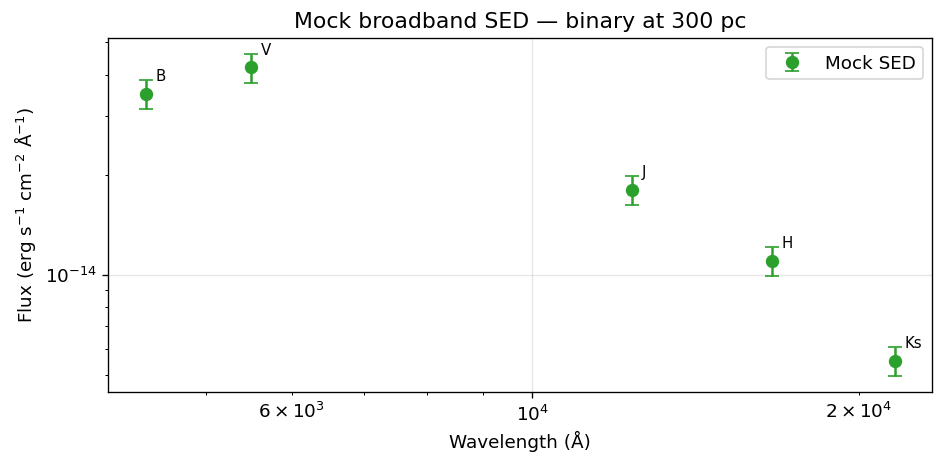

In [4]:
# Mock SED data -- approximate broadband fluxes for a ~6000K binary at 300 pc
# In practice, these come from catalog cross-matches (2MASS, WISE, etc.)
sed_dict = {
    "RA": 180.0,        # degrees (arbitrary for demo)
    "DEC": 30.0,        # degrees
    "dist": 300.0,      # parsec
    # Effective wavelengths in Angstroms for Johnson B, V, 2MASS J, H, Ks
    "wavelengths": np.array([4400, 5500, 12350, 16620, 21590]),
    # Mock fluxes in erg/s/cm^2/A (rough order-of-magnitude for this system)
    "fluxes": np.array([3.5e-14, 4.2e-14, 1.8e-14, 1.1e-14, 5.5e-15]),
    "flux_errs": np.array([3.5e-15, 4.2e-15, 1.8e-15, 1.1e-15, 5.5e-16]),
}

band_names = ["B", "V", "J", "H", "Ks"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(sed_dict["wavelengths"], sed_dict["fluxes"], yerr=sed_dict["flux_errs"],
            fmt="o", capsize=4, color="C2", markersize=7, label="Mock SED")
for wl, fl, name in zip(sed_dict["wavelengths"], sed_dict["fluxes"], band_names):
    ax.annotate(name, (wl, fl), textcoords="offset points", xytext=(6, 8), fontsize=9)
ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
ax.set_title(f"Mock broadband SED — binary at {sed_dict['dist']:.0f} pc")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

print(f"SED bands: {len(sed_dict['wavelengths'])}")
print(f"Distance: {sed_dict['dist']} pc")

## 3. Initialize EBMCMC (Joint LC + SED + RV)

Create the `EBMCMC` object with all three data types. This will:
- Extract observed data from the bundle into `data_dict` (LC and RV entries)
- Query the Edenhofer (2023) dust map for E(B-V) at the given coordinates and add the SED entry
- Build the template PHOEBE bundle for forward modeling
- Set `has_rv=True` (RV dataset detected) and `has_sed=True` (SED dict provided)

The parameter vector for this joint mode is 15-dimensional:
`[core(7)] + [SED block(2)] + [eta_sigma_lc(1)] + [RV block(2)] + [ecc(2)] + [psi_t0(1)]`

In [5]:
import tempfile, os

trace_dir = tempfile.mkdtemp(prefix="ebmcmc_demo_")

eb = EBMCMC(
    bundle=b,
    trace_dir=trace_dir,
    sed=sed_dict,
    datasets=["lc01_tess", "rv01"],   # LC + RV datasets
    eclipsing=True,
    ecc=True,
    new_run_dir="demo",
)

print(f"Data dict keys: {list(eb.data_dict.keys())}")
print(f"has_rv (RV dataset present): {eb.rvs}")
print(f"has_sed (SED data present):  {'sed' in eb.data_dict}")
print(f"Run dir: {eb.run_dir}")

Thu, 19 Mar 2026 12:42 ebmcmc.ebmcmc INFO    Adding dataset lc01_tess
Thu, 19 Mar 2026 12:42 ebmcmc.ebmcmc INFO    Adding dataset rv01
Integrating extinction map (this might take a couple of minutes)...
Optimizing map for querying (this might take a couple of seconds)...


Data dict keys: ['lc01_tess', 'rv01', 'sed']
has_rv (RV dataset present): True
has_sed (SED data present):  True
Run dir: /tmp/ebmcmc_demo_ii664a8m/run_demo


In [6]:
# Inspect the initial parameter vector
init_vals = eb.get_initial_values(ecc=True)

# Joint LC+SED+RV with ecc=True layout (15 parameters):
# [0-6] core + [7-8] SED block + [9] eta_sigma_lc + [10-11] RV block + [12-13] ecc + [14] psi_t0
param_names = [
    "u_q", "log_Msum", "log_teff1", "log_tefffrac",
    "log_rfrac", "logit_rsumfrac", "logit_cosi",
    "log_dist", "eta_alpha_sed",
    "eta_sigma_lc",
    "vgamma", "eta_sigma_rv",
    "ecc", "per0_rad", "psi_t0",
]

print(f"Parameter vector length: {len(init_vals)}")
print(f"\n{'Index':<6} {'Name':<20} {'Value':<12}")
print("-" * 40)
for i, (name, val) in enumerate(zip(param_names, init_vals)):
    print(f"{i:<6} {name:<20} {val:<12.4f}")

Parameter vector length: 15

Index  Name                 Value       
----------------------------------------
0      u_q                  -1.3863     
1      log_Msum             -1.1406     
2      log_teff1            8.6995      
3      log_tefffrac         -0.1431     
4      log_rfrac            -0.2336     
5      logit_rsumfrac       -0.3819     
6      logit_cosi           -2.3489     
7      log_dist             5.7038      
8      eta_alpha_sed        -4.7060     
9      eta_sigma_lc         -7.1951     
10     vgamma               -12.0000    
11     eta_sigma_rv         0.5413      
12     ecc                  0.0500      
13     per0_rad             1.5708      
14     psi_t0               0.0000      


## 4. Run the Sampler (Short Demo)

We run a very short chain for illustration. In production you would use the defaults (`max_n=100000`, `nwalkers=32`, `threads=16`).

You can also pass a `prior_info` dict to add informative priors (Gaia distance, RV-derived mass ratio, etc.).

In [ ]:
%%time

# Optional: informative Gaia distance prior
prior_info = {
    "gaia_dist": {
        "dist0": 300.0,    # central distance (pc)
        "dist_lo": 280.0,  # lower 1-sigma bound
        "dist_hi": 320.0,  # upper 1-sigma bound
        "ruwe": 1.0,       # Gaia RUWE (low = good astrometry)
    },
}

sampler = eb.sample(
    ecc=True,
    nwalkers=30,
    threads=30,
    max_n=500,       # very short for demo
    burn_in=100,
    prior_info=prior_info,
    use_ellc=True
)

print(f"\nChain shape: {sampler.get_chain().shape}")
print(f"  (steps, walkers, parameters)")

Thu, 19 Mar 2026 12:52 ebmcmc.ebmcmc INFO    Sampler starting with 1 steps completed.
Thu, 19 Mar 2026 12:52 ebmcmc.ebmcmc INFO    Getting sampler...
Thu, 19 Mar 2026 12:52 ebmcmc.ebmcmc INFO    Initial sampler moves: (<emcee.moves.stretch.StretchMove object at 0x7fc438a64a00>, <emcee.moves.de.DEMove object at 0x7fc438ac5270>)
Thu, 19 Mar 2026 12:52 ebmcmc.ebmcmc INFO    Running pilot phase for 249 steps (target total iteration=250).
Thu, 19 Mar 2026 12:58 BUNDLE       WARNING 'primary' probably has a radiative atm (teff=8310K>8000K), for which gravb_bol>=0.9 might be a better approx than gravb_bol=0.32.
Thu, 19 Mar 2026 12:58 BUNDLE       WARNING 'primary' probably has a radiative atm (teff=8310K>8000K), for which gravb_bol>=0.9 might be a better approx than gravb_bol=0.32.
Thu, 19 Mar 2026 12:58 BUNDLE       WARNING 'primary' probably has a radiative atm (teff=8310K>=8000K), for which irrad_frac_refl_bol>0.8 (suggestion: 1.0) might be a better approx than irrad_frac_refl_bol=0.60.
Th

## 5. Inspect the Chains

Plot walker traces for a few key parameters and the log-probability. With only 500 steps this won't be converged, but you can see the walkers exploring the posterior.

In [ ]:
chain = sampler.get_chain()           # (steps, walkers, ndim)
log_prob = sampler.get_log_prob()     # (steps, walkers)

# Select a few parameters to plot
plot_indices = [0, 1, 2, 6]  # u_q, log_Msum, log_teff1, logit_cosi
plot_names = ["u_q", "log_Msum", "log_teff1", "logit_cosi"]

fig, axes = plt.subplots(len(plot_indices) + 1, 1, figsize=(10, 2.2 * (len(plot_indices) + 1)), sharex=True)

# Log-probability trace
for w in range(chain.shape[1]):
    axes[0].plot(log_prob[:, w], alpha=0.3, lw=0.5)
axes[0].set_ylabel("log P")
axes[0].set_title("Walker traces")

# Parameter traces
for i, (idx, name) in enumerate(zip(plot_indices, plot_names)):
    ax = axes[i + 1]
    for w in range(chain.shape[1]):
        ax.plot(chain[:, w, idx], alpha=0.3, lw=0.5)
    ax.set_ylabel(name)

axes[-1].set_xlabel("Step")
plt.tight_layout()

## 6. Transform to Physical Parameters

Use `transform_params` to convert the unconstrained sampler vectors into physical quantities. Since this is a joint LC+SED+RV run, we recover both distance (from SED) and systemic velocity (from RV).

In [ ]:
# Flatten chain, discarding the first half as burn-in
discard = chain.shape[0] // 2
flat_chain = sampler.get_chain(flat=True, discard=discard)
print(f"Flat chain shape after discarding {discard} steps: {flat_chain.shape}")

# Transform each sample to physical parameters
# Joint mode: has_rv=True, has_sed=True
physical = []
for sample in flat_chain:
    tp = transform_params(sample, period=TRUTH["period"], has_rv=True, has_sed=True, ecc_bool=True)
    q, Msum, teff1, teff2, r1, r2, a, incl, dist, vgamma, ecc_val, per0_rad = tp
    physical.append([q, Msum, teff1, teff2, r1, r2, incl, dist, vgamma])

physical = np.array(physical)
phys_names = ["q", "Msum", "Teff1", "Teff2", "R1", "R2", "incl", "dist", "vgamma"]
truth_vals = [TRUTH["q"], None, TRUTH["teff1"], TRUTH["teff2"],
              TRUTH["requiv1"], TRUTH["requiv2"], TRUTH["incl"],
              TRUTH["distance"], TRUTH["vgamma"]]

# Print summary table
print(f"\n{'Parameter':<12} {'Median':>10} {'16%':>10} {'84%':>10} {'Truth':>10}")
print("-" * 56)
for i, name in enumerate(phys_names):
    lo, med, hi = np.percentile(physical[:, i], [16, 50, 84])
    truth_str = f"{truth_vals[i]:.2f}" if truth_vals[i] is not None else "---"
    print(f"{name:<12} {med:>10.2f} {lo:>10.2f} {hi:>10.2f} {truth_str:>10}")

## 7. Corner Plot

If `corner` is installed, make a corner plot for the key physical parameters.

In [ ]:
try:
    import corner

    # Select a subset for readability: q, Teff1, Teff2, R2, incl, dist, vgamma
    corner_idx = [0, 2, 3, 5, 6, 7, 8]
    corner_names = [phys_names[i] for i in corner_idx]
    corner_truths = [truth_vals[i] for i in corner_idx]

    fig = corner.corner(
        physical[:, corner_idx],
        labels=corner_names,
        truths=corner_truths,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 10},
    )
    fig.suptitle("Joint LC+SED+RV posterior (short demo chain -- not converged)", y=1.02, fontsize=13)

except ImportError:
    print("Install `corner` for a corner plot: pip install corner")
    
    # Fallback: simple 1D histograms
    fig, axes = plt.subplots(2, 5, figsize=(16, 5))
    for i, (ax, name) in enumerate(zip(axes.flat, phys_names)):
        ax.hist(physical[:, i], bins=30, density=True, alpha=0.7)
        if truth_vals[i] is not None:
            ax.axvline(truth_vals[i], color="r", ls="--", label="Truth")
        ax.set_xlabel(name)
        ax.legend(fontsize=8)
    # Hide unused subplot
    axes.flat[-1].set_visible(False)
    plt.tight_layout()

## 8. Alternative Configurations

The demo above used all three data types jointly. You can also run `ebmcmc` with any subset:

| Configuration | `datasets=` | `sed=` | Parameter vector |
|---|---|---|---|
| LC only | `["lc01_tess"]` | `None` | 7 core + 1 `eta_sigma_lc` + (ecc) + `psi_t0` |
| LC + SED | `["lc01_tess"]` | `sed_dict` | + 2 SED block (`log_dist`, `eta_alpha_sed`) |
| LC + RV | `["lc01_tess", "rv01"]` | `None` | + 2 RV block (`vgamma`, `eta_sigma_rv`) |
| **LC + SED + RV** | `["lc01_tess", "rv01"]` | `sed_dict` | + SED block + RV block (shown above) |

Below is a quick example of LC+RV only (no SED), to show how the parameter vector changes:

In [ ]:
trace_dir_rv = tempfile.mkdtemp(prefix="ebmcmc_demo_rv_")

eb_rv = EBMCMC(
    bundle=b,
    trace_dir=trace_dir_rv,
    sed=None,                              # no SED in this configuration
    datasets=["lc01_tess", "rv01"],        # LC + RV only
    eclipsing=True,
    ecc=True,
    new_run_dir="demo_rv",
)

print(f"Data dict keys: {list(eb_rv.data_dict.keys())}")
print(f"has_rv: {eb_rv.rvs},  has_sed: {'sed' in eb_rv.data_dict}")

# LC+RV (no SED) with ecc=True: [0-6] core + [7] eta_sigma_lc + [8-9] RV + [10-11] ecc + [12] psi_t0 = 13
init_rv = eb_rv.get_initial_values(ecc=True)
rv_param_names = [
    "u_q", "log_Msum", "log_teff1", "log_tefffrac",
    "log_rfrac", "logit_rsumfrac", "logit_cosi",
    "eta_sigma_lc",
    "vgamma", "eta_sigma_rv",
    "ecc", "per0_rad", "psi_t0",
]

print(f"\nLC+RV parameter vector (length {len(init_rv)}):")
print(f"{'Index':<6} {'Name':<20} {'Value':<12}")
print("-" * 40)
for i, (name, val) in enumerate(zip(rv_param_names, init_rv)):
    print(f"{i:<6} {name:<20} {val:<12.4f}")

print(f"\nCompare: joint LC+SED+RV has {len(eb.get_initial_values(ecc=True))} params, "
      f"LC+RV has {len(init_rv)} params (no log_dist, eta_alpha_sed)")

## Next Steps

The demo above used a very short chain (500 steps, 16 walkers) that is **not converged**. For real science:

- Use the defaults: `max_n=100000`, `nwalkers=32`, `threads=16`
- Run on an HPC cluster (e.g., NERSC Perlmutter) with `srun -n 1 -c 32`
- Check convergence via autocorrelation time (the sampler does this automatically and will stop early if converged)
- Discard burn-in based on the walker trace plots

### Other features not shown here

- **`prior_info` options**: `q_from_rv`, `asini_from_rv`, `t0` (von Mises phase prior), `msum_cap`
- **Non-eclipsing binaries**: Set `eclipsing=False` for ellipsoidal variables (applies non-eclipse constraints instead of sin(i) prior)
- **PHOEBE SED method**: Set `sed_method="phoebe"` for passband-integrated SED modeling via PHOEBE instead of `binarysed`

See the [README](README.md) for the full `prior_info` dictionary reference and parameter vector layout.